In [341]:
EXPERIMENT = "pattern"
SAVE_FIGURES = False

# Imports

In [342]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

from tqdm import tqdm

import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".95"

In [343]:
if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    os.makedirs("figures", exist_ok=True)

# Pattern Forward Model

This copy runs the three-cell-type pattern adhesion model: salt-and-pepper with shell.


In [344]:
from pathlib import Path
import importlib
import importlib.util
import json
from collections import namedtuple

NOTEBOOK_DIR = Path.cwd()

import pattern_istate_and_model as pattern_model

importlib.reload(pattern_model)

from IPython.display import Image as DisplayImage, display
import random
import numpy as onp

In [345]:
FORWARD_OUTDIR = NOTEBOOK_DIR / "pattern_forward_outputs"
FORWARD_OUTDIR.mkdir(exist_ok=True)

PATTERN = "salt-pepper-shell"
# J = np.array([3.8,3.8,0.9,3.8,0.9,0.8])  # [J11, J12, J13, J22, J23, J33]
# envelop + s&p
# J = np.array([3.2530967418684433, 2.973676847732232, 1.17428125590103, 3.1452662449814284, 1.2830031759728924, 1.8517135350777736])
J=np.array([3.5253170214589993, 3.7624176550789166, 0.8138586934573762, 1.0495001001102002, 2.8317232163533532, 2.2631641956631325])
N_CELLS = 90
TYPE_RATIOS = np.array([1,1,6])  # [type1, type2, type3]
# envelop + s&p
# TYPE_RATIOS = np.array([3,3,54])
# TYPE_RATIOS = np.array([24,26,10])
HIDE_TYPES = [3]  # one-based cell types to hide, e.g. [3] hides type 3
N_STEPS = 200
SEED = random.randint(0, 1000000)
# SEED = 0

key = jax.random.PRNGKey(SEED)
key, init_key, sim_key = jax.random.split(key, 3)

istate_pattern = pattern_model.build_istate(init_key, n_cells=N_CELLS, type_ratios=TYPE_RATIOS)
model_pattern = pattern_model.build_model(J, initial_type_fractions=TYPE_RATIOS / TYPE_RATIOS.sum())
trajectory_pattern = jxm.simulate(model_pattern, istate_pattern, sim_key, N_STEPS, history=True)
if isinstance(trajectory_pattern, tuple):
    trajectory_pattern = trajectory_pattern[0]
fstate_pattern = jax.tree_util.tree_map(lambda x: x[-1], trajectory_pattern)

initial_loss = float(pattern_model.pattern_loss(istate_pattern, pattern=PATTERN))
loss = float(pattern_model.pattern_loss(fstate_pattern, pattern=PATTERN))
print(f"Initial loss: {initial_loss:.3f}")
print(f"Final loss: {loss:.3f}")


Initial loss: -1.138
Final loss: -1.604


In [ ]:
def _load_translucent_sphere_plotter(notebook_dir):
    plot_path = Path(notebook_dir) / "translucent-3d-plotting.py"
    spec = importlib.util.spec_from_file_location("translucent_3d_plotting", plot_path)
    sphere_plotting = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(sphere_plotting)
    return sphere_plotting.plot_translucent_spheres


def pattern_metrics(state, *, pattern, **loss_kwargs):
    positions = onp.asarray(state.position)
    type_idx = onp.asarray(onp.argmax(state.celltype, axis=1))
    metrics = {"loss": float(pattern_model.pattern_loss(state, pattern=pattern, **loss_kwargs))}
    for i in range(3):
        mask = type_idx == i
        if onp.any(mask):
            type_positions = positions[mask]
            type_center = type_positions.mean(axis=0)
            dist = onp.sqrt(onp.sum((type_positions - type_center) ** 2, axis=-1) + 1e-8)
            metrics[f"mean_radius_type_{i + 1}"] = float(onp.mean(dist))
        else:
            metrics[f"mean_radius_type_{i + 1}"] = 0.0
        metrics[f"count_type_{i + 1}"] = int(onp.sum(mask))
    return metrics


def visible_cell_mask(state, hidden_types=None):
    hidden_types = set(hidden_types or [])
    if not hidden_types:
        return None
    type_idx = onp.asarray(onp.argmax(state.celltype, axis=1)) + 1
    return ~onp.isin(type_idx, list(hidden_types))


def hidden_filename(filename, hidden_types):
    path = Path(filename)
    hidden_tag = "-hidden-" + "-".join(str(t) for t in hidden_types)
    return f"{path.stem}{hidden_tag}{path.suffix}"


def save_pattern_state_visualization(*, outdir, state, title, filename, target_j, pattern, hidden_types=None, **loss_kwargs):
    outdir = Path(outdir)
    outdir.mkdir(exist_ok=True)
    path = outdir / filename
    hidden_types = list(hidden_types or [])
    plot_translucent_spheres = _load_translucent_sphere_plotter(NOTEBOOK_DIR)
    metrics = pattern_metrics(state, pattern=pattern, **loss_kwargs)

    plot_translucent_spheres(state, path, title, metrics, target_j)
    result = {"path": str(path), "hidden_path": None, "metrics": metrics}

    if hidden_types:
        hidden_path = outdir / hidden_filename(filename, hidden_types)
        cell_mask = visible_cell_mask(state, hidden_types)
        hidden_title = f"{title} hidden types {hidden_types}"
        plot_translucent_spheres(state, hidden_path, hidden_title, metrics, target_j, cell_mask=cell_mask)
        result["hidden_path"] = str(hidden_path)

    return result


def display_preview(preview, width=420):
    display(DisplayImage(filename=preview["path"], width=width))
    if preview.get("hidden_path") is not None:
        display(DisplayImage(filename=preview["hidden_path"], width=width))


initial_preview = save_pattern_state_visualization(
    outdir=FORWARD_OUTDIR,
    state=istate_pattern,
    title="pattern initial state",
    filename="pattern-initial-state.png",
    target_j=J,
    pattern=PATTERN,
)

final_preview = save_pattern_state_visualization(
    outdir=FORWARD_OUTDIR,
    state=fstate_pattern,
    title="pattern forward final state",
    filename="pattern-forward-final-state.png",
    target_j=J,
    pattern=PATTERN,
    hidden_types=HIDE_TYPES,
)

display_preview(initial_preview, width=420)
display_preview(final_preview, width=420)


In [ ]:
# animation_outputs = forward_viz.save_forward_animation(
#     outdir=FORWARD_OUTDIR,
#     istate=istate_pattern,
#     trajectory=trajectory_pattern,
# )

# animation_outputs["animation"]

# Load Pattern Results

In [ ]:
def _count_eqx_arrays(path):
    """Count NumPy arrays in an Equinox leaf stream without deserializing a PyTree."""
    count = 0
    with open(path, "rb") as fh:
        while True:
            try:
                onp.load(fh, allow_pickle=False)
                count += 1
            except EOFError:
                break
    return count


def _get_hyper(opt_hyper, lower_name, upper_name=None, default=None):
    if lower_name in opt_hyper:
        return opt_hyper[lower_name]
    if upper_name is not None and upper_name in opt_hyper:
        return opt_hyper[upper_name]
    return default


def pattern_loss_kwargs_from_hyper(opt_hyper):
    defaults = pattern_model.pattern_loss.__kwdefaults__ or {}
    return {
        name: float(_get_hyper(opt_hyper, name, name.upper(), default))
        for name, default in defaults.items()
        if name != "pattern"
    }


def load_run_data_patterns(run_id, root="trained_models_patterns_salt_pepper_sweep/wfrac_0/w12_0/ratio_1-1-4/ncells_60"):
    """Load training log, initial state, and trained model for a pattern run."""
    root = Path(root)
    with open(root / "train-pattern-opt-hyperparams.json", "r") as f:
        opt_hyper = json.load(f)

    run_dir = root / f"train-pattern-{run_id}"
    progress_path = run_dir / "training_progress.json"
    with open(progress_path, "r") as f:
        progress = json.load(f)

    TrainingLog = namedtuple("TrainingLog", ["loss", "val_loss"])
    train_loss = [row["train_loss"] for row in progress]
    val_loss = [row["val_loss"] for row in progress] if progress and progress[0].get("val_loss") is not None else None
    training_log = TrainingLog(train_loss, val_loss)

    n_cells = int(_get_hyper(opt_hyper, "n_cells", "N_CELLS", 60))
    type_ratios = np.asarray(_get_hyper(opt_hyper, "type_ratios", "TYPE_RATIOS", [1.0, 1.0, 1.0]), dtype=float)
    initial_type_fractions = np.asarray(
        opt_hyper.get("initial_type_fractions", type_ratios / type_ratios.sum()),
        dtype=float,
    )

    key = jax.random.PRNGKey(0)
    istate = pattern_model.build_istate(key, n_cells=n_cells, type_ratios=type_ratios)
    model_template = pattern_model.build_model(
        np.array([2.0, 2.0, 2.0, 2.0, 2.0, 2.0]),
        initial_type_fractions=initial_type_fractions,
    )

    with open(run_dir / f"init-pattern-{run_id}.eqx", "rb") as fh:
        initial_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    with open(run_dir / f"trained-pattern-{run_id}.eqx", "rb") as fh:
        trained_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    print(f"Loaded {len(train_loss)} logged epochs from {progress_path}")
    print(f"Initial ratios: {type_ratios.tolist()}; initial fractions: {initial_type_fractions.tolist()}")
    return opt_hyper, training_log, istate, initial_model, trained_model


# Single Run

In [ ]:
RUN_ID = 3

In [ ]:
opt_hyper, training_log, istate, initial_model, trained_model = load_run_data_patterns(
    RUN_ID
)

Loaded 201 logged epochs from trained_models_patterns_salt_pepper_sweep/wfrac_0/w12_0/ratio_1-1-4/ncells_60/train-pattern-3/training_progress.json
Initial ratios: [1.0, 1.0, 4.0]; initial fractions: [0.16666666666666666, 0.16666666666666666, 0.6666666666666666]


## Loss Curves


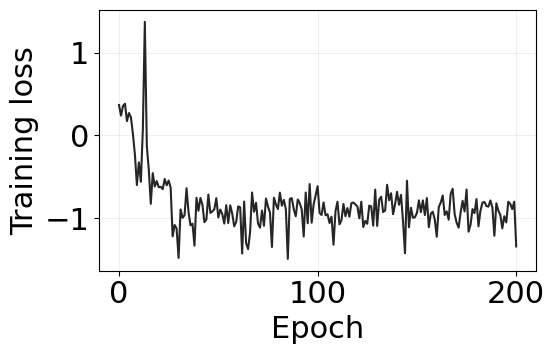

In [ ]:
epochs = np.arange(len(training_log.loss))

if training_log.val_loss is None:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(epochs, training_log.loss, color="black", alpha=0.85)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training loss")
    ax.grid(alpha=0.2)
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs, training_log.loss, color="black", alpha=0.85)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Training loss")
    ax[0].grid(alpha=0.2)

    ax[1].plot(epochs, training_log.val_loss, color="maroon", alpha=0.85)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Validation loss")
    ax[1].grid(alpha=0.2)

fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(f"figures/loss_curves_{EXPERIMENT}-{RUN_ID}.svg", dpi=300)

## Forward Comparison


In [ ]:
def _simulate_final_state(model, istate, key, n_sim_steps):
    result = jxm.simulate(model, istate, key, n_sim_steps)
    return result[0] if isinstance(result, tuple) else result


TRAINED_OUTDIR = NOTEBOOK_DIR / "trained_pattern_forward_outputs"
TRAINED_OUTDIR.mkdir(exist_ok=True)

PATTERN = _get_hyper(opt_hyper, "pattern", "PATTERN", "salt-pepper-shell")
N_SIM_STEPS = int(_get_hyper(opt_hyper, "n_steps", "N_STEPS", 50))
loss_kwargs = pattern_loss_kwargs_from_hyper(opt_hyper)

initial_j = pattern_model.visible_j_from_raw_j(initial_model.raw_j)
trained_j = pattern_model.visible_j_from_raw_j(trained_model.raw_j)
initial_frac = pattern_model.visible_fractions_from_raw_fractions(initial_model.raw_fractions)
trained_frac = pattern_model.visible_fractions_from_raw_fractions(trained_model.raw_fractions)

key = jax.random.PRNGKey(random.randint(0, 10000))
key, initial_type_key, trained_type_key, initial_sim_key, trained_sim_key = jax.random.split(key, 5)
istate_initial_model, _ = pattern_model.sample_initial_celltypes(initial_model, istate, initial_type_key)
istate_trained_model, _ = pattern_model.sample_initial_celltypes(trained_model, istate, trained_type_key)

fstate_initial_model = _simulate_final_state(initial_model, istate_initial_model, initial_sim_key, N_SIM_STEPS)
fstate_trained_model = _simulate_final_state(trained_model, istate_trained_model, trained_sim_key, N_SIM_STEPS)

base_state_loss = float(pattern_model.pattern_loss(istate, pattern=PATTERN, **loss_kwargs))
initial_model_loss = float(pattern_model.pattern_loss(fstate_initial_model, pattern=PATTERN, **loss_kwargs))
trained_model_loss = float(pattern_model.pattern_loss(fstate_trained_model, pattern=PATTERN, **loss_kwargs))

print("loss kwargs from training hyperparameters:", loss_kwargs)
print("initial J:", onp.asarray(initial_j).tolist())
print("trained J:", onp.asarray(trained_j).tolist())
print("initial fractions:", onp.asarray(initial_frac).tolist())
print("trained fractions:", onp.asarray(trained_frac).tolist())
print(f"base initial state loss: {base_state_loss:.4f}")
print(f"final state with initial J/fractions loss: {initial_model_loss:.4f}")
print(f"final state with trained J/fractions loss: {trained_model_loss:.4f}")


loss kwargs from training hyperparameters: {'shell_distance_weight': 1.0, 'w12': 0.0, 'w33': 1.0, 'w_media1': 10.0, 'w_media2': 10.0, 'w_media3': 10.0}
initial J: [0.841795262694427, 2.249973571210403, 2.1334648593967565, 1.2471564119336755, 2.571150043776518, 3.1829206164324573]
trained J: [0.8451610893389494, 3.519482773785467, 2.6947490288728773, 1.2707884610485625, 2.7975227820122286, 1.8508633106868058]
initial fractions: [0.16666666666666666, 0.16666666666666666, 0.6666666666666666]
trained fractions: [0.008575444094636729, 0.007157943494555456, 0.9842666124108078]
base initial state loss: 0.1606
final state with initial J/fractions loss: 1.0415
final state with trained J/fractions loss: -0.4590


KeyboardInterrupt: 

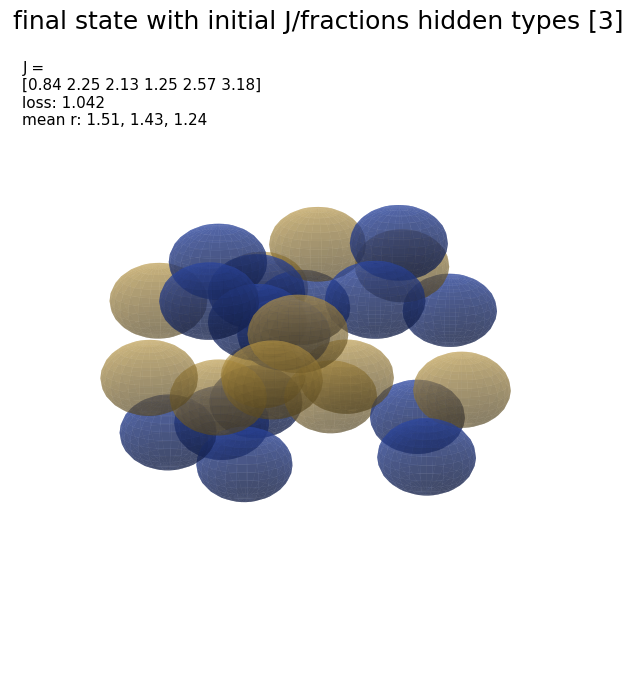

In [ ]:
base_preview = save_pattern_state_visualization(
    outdir=TRAINED_OUTDIR,
    state=istate,
    title="base initial state from ratios",
    filename=f"{EXPERIMENT}-{RUN_ID}-base-initial-state.png",
    target_j=trained_j,
    pattern=PATTERN,
    **loss_kwargs,
)

untrained_preview = save_pattern_state_visualization(
    outdir=TRAINED_OUTDIR,
    state=fstate_initial_model,
    title="final state with initial J/fractions",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-initial-j.png",
    target_j=initial_j,
    pattern=PATTERN,
    hidden_types=HIDE_TYPES,
    **loss_kwargs,
)

trained_preview = save_pattern_state_visualization(
    outdir=TRAINED_OUTDIR,
    state=fstate_trained_model,
    title="final state with trained J/fractions",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-trained-j.png",
    target_j=trained_j,
    pattern=PATTERN,
    hidden_types=HIDE_TYPES,
    **loss_kwargs,
)

display_preview(base_preview, width=360)
display_preview(untrained_preview, width=360)
display_preview(trained_preview, width=360)